In [10]:
import pandas as pd

df = pd.read_csv("/content/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
# Convert M/B to 1/0
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [12]:
X = df.drop(["id", "diagnosis", "Unnamed: 32"], axis=1)
y = df["diagnosis"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [15]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:,1]

In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt)
roc_dt = roc_auc_score(y_test, y_prob_dt)

# AdaBoost
acc_ada = accuracy_score(y_test, y_pred_ada)
roc_ada = roc_auc_score(y_test, y_prob_ada)

print("Decision Tree Accuracy:", acc_dt)
print("Decision Tree ROC-AUC :", roc_dt)

print()

print("AdaBoost Accuracy:", acc_ada)
print("AdaBoost ROC-AUC :", roc_ada)

Decision Tree Accuracy: 0.9473684210526315
Decision Tree ROC-AUC : 0.9439895185063871

AdaBoost Accuracy: 0.9649122807017544
AdaBoost ROC-AUC : 0.9924664264657714


In [17]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "AdaBoost"],
    "Accuracy": [acc_dt, acc_ada],
    "ROC-AUC": [roc_dt, roc_ada]
})

results

,Model,Accuracy,ROC-AUC
0,Decision Tree,0.947368,0.943990
1,AdaBoost,0.964912,0.992466


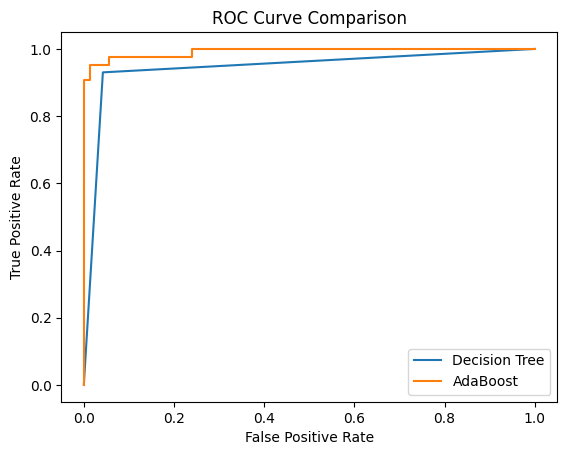

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)

plt.figure()

plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()